# PREPROCESSING

## Load Data & Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pathlib import Path

pd.set_option('display.max_columns', None)

# Load data
data_path = Path('../data/raw/telco_customer_churn.csv')
df = pd.read_csv(data_path)

print(f"Original shape: {df.shape}")
df.head()

Original shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Fix TotalCharges Issue

In [2]:
print("FIXING TotalCharges")
print("=" * 60)

print(f"Before fix - dtype: {df['TotalCharges'].dtype}")

# Convert to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"After conversion - dtype: {df['TotalCharges'].dtype}")
print(f"Missing values created: {df['TotalCharges'].isnull().sum()}")

# Check the rows that is null — usually new customer (tenure=0)
missing_rows = df[df['TotalCharges'].isnull()]
print(f"\nRows with missing TotalCharges (tenure check):")
print(missing_rows[['tenure', 'MonthlyCharges', 'TotalCharges']])

# Fix: Fill with 0 (because tenure=0, so never charged)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"\nMissing values after fill: {df['TotalCharges'].isnull().sum()}")

FIXING TotalCharges
Before fix - dtype: object
After conversion - dtype: float64
Missing values created: 11

Rows with missing TotalCharges (tenure check):
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

Missing values after fill: 0


## Drop Irrelevant Columns

In [3]:
print("DROPPING IRRELEVANT COLUMNS")
print("=" * 60)

# customerID: unique identifier, no predictive value
df = df.drop('customerID', axis=1)

print(f"Shape after dropping customerID: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

DROPPING IRRELEVANT COLUMNS
Shape after dropping customerID: (7043, 20)
Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Encode Target Variable

In [4]:
print("ENCODING TARGET (Churn)")
print("=" * 60)

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f"Churn value counts:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

ENCODING TARGET (Churn)
Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


## Encode Binary Categorical Features

In [5]:
print("ENCODING BINARY FEATURES (Yes/No)")
print("=" * 60)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    print(f"{col}: {df[col].unique()}")
    df[col] = (df[col] == 'Yes').astype(int)

# gender: Male/Female -> 0/1
df['gender'] = (df['gender'] == 'Male').astype(int)

# SeniorCitizen sudah 0/1 dari awal, gak perlu diubah
print(f"\nSeniorCitizen already binary: {df['SeniorCitizen'].unique()}")

print("\nBinary encoding done.")
df[binary_cols + ['gender', 'SeniorCitizen']].head()

ENCODING BINARY FEATURES (Yes/No)
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
PaperlessBilling: ['Yes' 'No']

SeniorCitizen already binary: [0 1]

Binary encoding done.


,Partner,Dependents,PhoneService,PaperlessBilling,gender,SeniorCitizen
0,1,0,0,1,0,0
1,0,0,1,0,1,0
2,0,0,1,1,1,0
3,0,0,0,0,1,0
4,0,0,1,1,0,0


## Encode Multi-Category Features (One-Hot)

In [6]:
print("ONE-HOT ENCODING MULTI-CATEGORY FEATURES")
print("=" * 60)

multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

for col in multi_cat_cols:
    print(f"{col}: {df[col].unique()}")

print(f"\nShape before one-hot: {df.shape}")

# One-hot encode, drop_first=True to avoid multicollinearity
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print(f"Shape after one-hot: {df.shape}")
print(f"\nNew columns created:")
new_cols = [col for col in df.columns if any(mc in col for mc in multi_cat_cols)]
print(new_cols)

ONE-HOT ENCODING MULTI-CATEGORY FEATURES
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Shape before one-hot: (7043, 20)
Shape after one-hot: (7043, 31)

New columns created:
['MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service'

In [7]:
# Convert bool columns to int (0/1)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Converted {len(bool_cols)} boolean columns to int")
print(f"\nFinal dtypes check:")
print(df.dtypes.value_counts())

Converted 21 boolean columns to int

Final dtypes check:
int64      29
float64     2
Name: count, dtype: int64


## Checking Numerical Features Outlier

OUTLIER CHECK (Numeric Features)


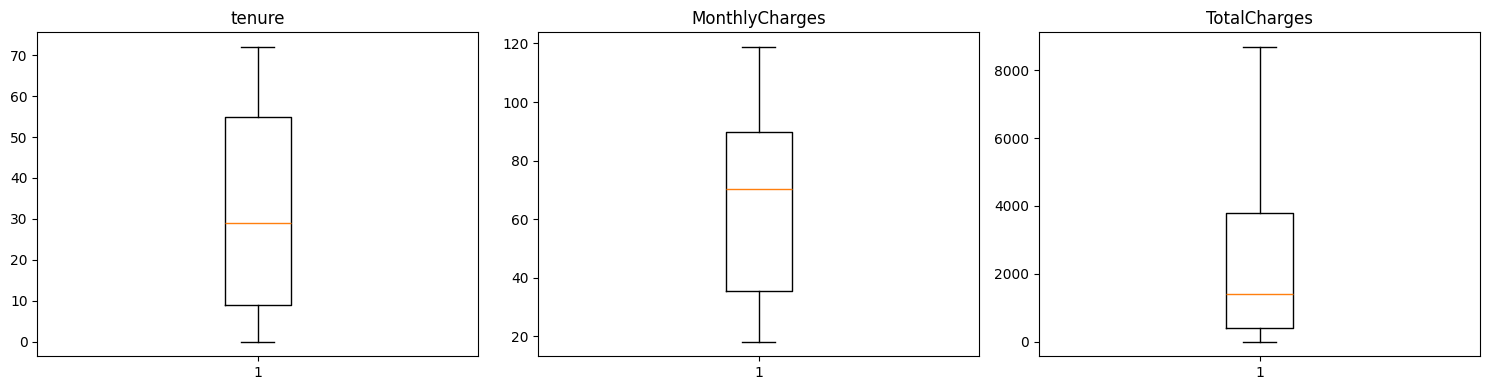

tenure: 0 outliers detected
MonthlyCharges: 0 outliers detected
TotalCharges: 0 outliers detected


In [8]:
print("OUTLIER CHECK (Numeric Features)")
print("=" * 60)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# IQR method for quantify outliers
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")

## Check Before Split

In [9]:
print("FINAL DATA CHECK")
print("=" * 60)

print(f"Final shape: {df.shape}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nAll columns are numeric: {all(df.dtypes != 'object')}")

# Preview
df.head()

FINAL DATA CHECK
Final shape: (7043, 31)

Missing values: 0

Data types:
int64      29
float64     2
Name: count, dtype: int64

All columns are numeric: True


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## Save Preprocessed Data

In [10]:
# Save intermediate result — full preprocessed data (before split)
output_path = Path('../data/processed/telco_preprocessed.csv')
df.to_csv(output_path, index=False)

print(f"Saved preprocessed data to {output_path}")
print(f"Shape: {df.shape}")

Saved preprocessed data to ..\data\processed\telco_preprocessed.csv
Shape: (7043, 31)
